In [302]:
import numpy as np
import string
import re
import matplotlib.pyplot as plt

In [303]:
def insert(stack, process_id, process_weight):
    num_to_letter_map = {i: letter for i, letter in enumerate(string.ascii_lowercase)}
    tags = [str(process_id)+num_to_letter_map[a] for a in range(process_weight)]
    min_len = min(stack, key=len)
    min_len_idx = stack.index(min_len)
    for tag in tags:
        stack[min_len_idx].append(tag)

def delete_from_list(list_of_tags, process_id):
    to_remove = []
    for tag in list_of_tags:
        num = ''.join(re.findall(r'[0-9]+', tag))
        if num == str(process_id):
            to_remove.append(tag)
    for tag in to_remove:
        list_of_tags.remove(tag)

def delete(stack, process_id):
    list_id = -1
    for list_of_tags in stack:
        for tag in list_of_tags:
            num = ''.join(re.findall(r'[0-9]+', tag))
            if num == str(process_id):
                list_id = stack.index(list_of_tags)
                break
        if list_id != -1:
            break
    if list_id < 0:
        print(f"Process with id {process_id} not found")
    else:
        delete_from_list(stack[list_id], process_id)
    
def find_last_tag_nums(list_of_tags):
    tag_str = ''.join(list_of_tags)
    tag_list = re.split(r'[a-z]+', tag_str)[:-1]
    counts = {i: tag_list.count(i) for i in set(tag_list)}
    #print(tag_str,tag_list,counts)
    return counts

def clear_extra_tags(stack, procs):
    num_to_letter_map = {i: letter for i, letter in enumerate(string.ascii_lowercase)}
    for list_of_tags in stack:
        if list_of_tags:
            max_true_tag = {str(a): num_to_letter_map[b-1] for a, b in procs.items()}
            to_remove = []
            for tag in list_of_tags:
                letter = ''.join(re.findall(r'[a-z]+', tag))
                num = ''.join(re.findall(r'[0-9]+', tag))
                if letter > max_true_tag[num]:
                    to_remove.append(tag)
            for tag in to_remove:
                list_of_tags.remove(tag)

def clear_ghost_tags(stack):
    for i in range(len(stack)):
        if len(stack[i]) > 0:
            if stack[i][0] == 'x':
                stack[i] = []


#ATTENTION: sorted functions might be replaced by search with lower complexity!
def balance(stack):
    num_to_letter_map = {i: letter for i, letter in enumerate(string.ascii_lowercase)}

    #b = len(stack)
    min_len = min(stack, key=len)
    min_len_idx = stack.index(min_len)
    max_elem_idx = -1
    max_elems = -1
    for i in range(len(stack)):
        num_elems = len(find_last_tag_nums(stack[i]))
        if num_elems > max_elems:
            max_elems = num_elems
            max_elem_idx = i    
    
    ##Move shortest process from list with most elements to shortest list
    if max_elems > 1 and len(stack[max_elem_idx]) > len(stack[min_len_idx]):
        shortest_idx = -1
        shortest_weight = -1
        if len(stack[max_elem_idx]) > 0:
            last_nums = find_last_tag_nums(stack[max_elem_idx])
            last_nums = dict(sorted(last_nums.items(), key=lambda item: item[1]))
            #print(last_nums)
            shortest_idx = list(last_nums.keys())[0]
            shortest_weight = last_nums[shortest_idx]
        #print(max_elem_idx,shortest_idx)
        delete_from_list(stack[max_elem_idx], shortest_idx)
        for i in range(shortest_weight):
            stack[min_len_idx].append(str(shortest_idx)+num_to_letter_map[i])

    max_len = max(stack, key=len)
    max_len_idx = stack.index(max_len)

    ##Balance the rest of the lists by adding tags to the shorter ones
    for i in range(len(stack)):
        if len(stack[i]) == 0:
            continue
        dif = len(stack[max_len_idx]) - len(stack[i])
        last_nums = find_last_tag_nums(stack[i])
        last_nums = dict(sorted(last_nums.items(), key=lambda item: item[1], reverse=True)) #Sort by value to give higer weighted elements more priority
        last_tags = [a+num_to_letter_map[b]+'r' for a,b in last_nums.items()]
        while dif > len(last_tags):
            last_nums = {k: v+1 for k, v in last_nums.items()}
            last_nums = dict(sorted(last_nums.items(), key=lambda item: item[1], reverse=True))
            last_tags += [a+num_to_letter_map[b]+'r' for a,b in last_nums.items()]
        #print(last_tags)

        k = 0
        #print(dif)
        for j in range(len(stack[i])-dif, len(stack[i])):
            stack[i].append(last_tags[k])
            #print(stack[i][j],end=' ')
            k = (k+1) % len(last_tags)
        #print(stack[i])
    
    #add ghost nodes
    for i in range(len(stack)):
        if len(stack[i]) == 0:
            stack[i] = ['x' for _ in range(len(stack[max_len_idx]))]
        

    

In [304]:
def circle_with_tag(x, y, tag, radius=0.1, border_color='black', text_color='black'):
    circle = plt.Circle((x, y), radius, fill=False, edgecolor=border_color)
    plt.gca().add_patch(circle)
    plt.text(x, y, tag, horizontalalignment='center', verticalalignment='center', color=text_color)

def arrow(x1, y1, x2, y2, head_length=0.1):
    plt.arrow(x1, y1, x2-x1, y2-y1, head_width=0.05, head_length=head_length, fc='lightblue', ec='gray')

def plot_process(b, process_id, process_weight, xpos=0, ypos=0, sign=''):
    plt.text(2*xpos, ypos/2, sign, horizontalalignment='center', verticalalignment='center', fontsize=12)
    ## Plot
    step = 0.5
    radius = 0.15
    hl = 0.1 # head length
    positions = []
    for i in range(process_weight*b):
        x = xpos + i*step
        y = ypos
        positions.append((x, y))
    for i in range(0,process_weight*b,b):
        x1 = positions[i][0]
        y1 = positions[i][1]
        x2 = x1+step
        y2 = y1
        circle_with_tag(x1, y1, str(process_id)+string.ascii_lowercase[i//b], radius)
        arrow(x1+radius, y1, x2-radius-hl, y2, head_length=hl)
        for j in range(1,b):
            x1 = positions[i+j][0]
            y1 = positions[i+j][1]
            x2 = x1+step
            y2 = y1
            circle_with_tag(x1, y1, 'x', radius)
            arrow(x1+radius, y1, x2-radius-hl, y2, head_length=hl)

def plot_graph(nodes, edges, ypos=0, process=None, sign=''):
    ## Plot
    step = 0.5
    radius = 0.15
    hl = 0.1 # head length
    positions = []
    for i in range(len(nodes)):
        x = i*step
        y = ypos
        positions.append((x, y))
    for i in range(len(edges)):
        x1 = positions[i][0]
        y1 = positions[i][1]
        x2 = positions[i+1][0]
        y2 = positions[i+1][1]
        if edges[i][0][-1] == 'r':
            circle_with_tag(x1, y1, edges[i][0][:-1], radius, border_color='grey', text_color='grey')
        else:
            circle_with_tag(x1, y1, edges[i][0], radius)
        arrow(x1+radius, y1, x2-radius-hl, y2, head_length=hl)
    x1 = positions[len(edges)][0]
    y1 = positions[len(edges)][1]
    x2 = x1+step
    y2 = y1
    if edges[len(edges)-1][1][-1] == 'r':
        circle_with_tag(x1, y1, edges[len(edges)-1][1][:-1], radius, border_color='grey', text_color='grey')
    else:
        circle_with_tag(x1, y1, edges[len(edges)-1][1], radius)
    arrow(x1+radius, y1, x2-radius-hl, y2, head_length=hl)

    if process:
        plot_process(len(stack), process[0], process[1], xpos=positions[0][0], ypos=positions[0][1]-1, sign=sign)

    plt.axis('equal')
    plt.axis('off')
    plt.show()

def plot_stack_graph(stack, ypos=0, process=None, sign=''):
    len0 = len(stack[0])
    for i in range(1, len(stack)):
        if len(stack[i]) != len0:
            print("Cannot plot graph, lists have different lengths")
            return
    if len0 == 0:
        print("Cannot plot graph, lists are empty")
        return
    
    nodes = []
    for l in stack:
        if l:
            nodes += l
    edges = []
    for i in range(len0):
        for j in range(len(stack)-1):
            edges.append((stack[j][i], stack[j+1][i]))
        if i < len0-1:
            edges.append((stack[-1][i], stack[0][i+1]))
        #else:
        #    edges.append((stack[-1][i], stack[0][0]))
    
    ## Plot
    plot_graph(nodes, edges, ypos, process, sign)


In [305]:
# proc = {0:2, 1:1, 2:3, 3:1, 4:2, 5:1}
# b = 3
# stack = [[] for _ in range(b)]

# for p in proc:
#     plot_stack_graph(stack, ypos=0, process=(p, proc[p]), sign='+')
#     #print(stack)
#     clear_ghost_tags(stack)
#     #print(stack)
#     clear_extra_tags(stack, proc)
#     #print(stack)
#     insert(stack, p, proc[p])
#     #print(stack)  
#     balance(stack)
#     print(stack)
#     #print()
# plot_stack_graph(stack, ypos=0)
# print(stack)
# #print()

# to_delete = [0, 3, 5]
# for p in to_delete:
#     plot_stack_graph(stack, ypos=0, process=(p, proc[p]), sign='-')
#     #print(stack)
#     delete(stack, p)
#     #print(stack)
#     clear_ghost_tags(stack)
#     #print(stack)
#     clear_extra_tags(stack, proc)
#     #print(stack)
#     balance(stack)
#     print(stack)
#     #print()
# plot_stack_graph(stack, ypos=0)
# print(stack)

In [306]:
# proc = {0:5, 1:1, 2:1, 3:3, 4:1, 5:1}
# N = len(proc)
# b = 3

# stack = [[] for _ in range(b)]
# for p in proc:
#     plot_stack_graph(stack, ypos=0, process=(p, proc[p]), sign='+')
#     #print(stack)
#     clear_ghost_tags(stack)
#     #print(stack)
#     clear_extra_tags(stack, proc)
#     #print(stack)
#     insert(stack, p, proc[p])
#     #print(stack)  
#     balance(stack)
#     print(stack)
#     #print()
# plot_stack_graph(stack, ypos=0)
# print(stack)

# to_delete = [2, 3, 0, 1, 5, 4]
# for p in to_delete:
#     plot_stack_graph(stack, ypos=0, process=(p, proc[p]), sign='-')
#     #print(stack)
#     delete(stack, p)
#     #print(stack)
#     clear_ghost_tags(stack)
#     #print(stack)
#     clear_extra_tags(stack, proc)
#     #print(stack)
#     balance(stack)
#     print(stack)
#     #print()
# plot_stack_graph(stack, ypos=0)
# print(stack)

# Algorithm
### Insertion
1. The process to be inserted is represented by $w$ nodes, separated by $b-1$ ghost nodes.
2. In the graph, replace all repeated nodes by ghost nodes.
3. Locate the first ghost node in the graph from left to right. Store its position in $r_g$.
4. Take the process located at $r_g+b$ and shift all its nodes $b$ units to the left.
5. Repeat steps 3 and 4 until you get to the right end of the graph and there are no more processes to shift to the left.
6. Insert the process in the location of the first ghost node found in the updated graph.
7. Add or erase ghost nodes from the right until the length of the graph is a multiple of $b$.
8. Go through the remaining ghost nodes from left to right, filling them with the repetition of nodes located $b$ units to their left or right. 
### Deletion
1. In the graph, replace all repeated nodes by ghost nodes.
2. Locate the first node of the process to remove and replace all of its nodes by ghost nodes.
3. Locate the first ghost node in the graph from left to right. Store its position in $r_g$.
4. Take the process located at $r_g+b$ and shift all its nodes $b$ units to the left.
5. Repeat steps 3 and 4 until you get to the right end of the graph and there are no more processes to shift to the left.
7. Add or erase ghost nodes from the right until the length of the graph is a multiple of $b$.
8. Go through the remaining ghost nodes from left to right, filling them with the repetition of nodes located $b$ units to their left or right. 


In [317]:
def process(id, weight):
    proc_string = ''
    for i in range(weight):
        proc_string += str(id)+string.ascii_lowercase[i]+','
        for j in range(1, b):
            proc_string += 'x'+','
    return proc_string.split(',')[:-1]

def repeated_to_ghost(gr):
    for i in range(len(gr)):
        if gr[i][-1] == 'r':
            gr[i] = 'x'

def shift_processes_left(gr, b):
    for k in range(b): #shift all stacks
        pos_1st_ghost = -1 
        try:
            pos_1st_ghost = [gr[i] for i in range(k,len(gr),b)].index('x')*b+k
        except ValueError:
            pos_1st_ghost = len(gr)
        if pos_1st_ghost < len(gr):
            for i in range(pos_1st_ghost, len(gr)-(b-k), b):
                gr[i] = gr[i+b] 
            if pos_1st_ghost < len(gr)-(b-k):
                gr[len(gr)-(b-k)] = 'x'

def merge(gr, p, pos_ini=None):
    pos_1st_ghost = -1
    if pos_ini:
        pos_1st_ghost = pos_ini
    else:
        try:
            pos_1st_ghost = gr.index('x')
        except ValueError:
            pos_1st_ghost = len(gr)
    if pos_1st_ghost == len(gr):
        gr += p
        return
    j = 0
    for i in range(pos_1st_ghost, len(gr)):
        j = i - pos_1st_ghost
        if j >= len(p):
            break
        if gr[i] == 'x' and p[j] != 'x':
            gr[i] = p[j]
    for k in range(j+1,len(p)):
        gr.append(p[k])

def delete(b, gr, p):
    pid = ''.join(re.findall(r'[0-9]+', p[0]))
    first_pos = -1
    for i in range(len(gr)):
        num = ''.join(re.findall(r'[0-9]+', gr[i]))
        if num == pid:
            first_pos = i
            break
    if first_pos == -1:
        print(f"Process with id {pid} not found")
    else:
        for i in range(first_pos, first_pos+len(p), b):
            gr[i] = 'x'

def balance_graph(gr, b):
    #Get the processor with the shortest load
    shortest_stack_idx = -1
    shortest_stack_len = float('inf')
    stack_lengths = []
    for idx in range(b):
        stack_len = len([gr[i] for i in range(idx, len(gr), b) if gr[i] != 'x'])
        stack_lengths.append(stack_len)
        if stack_len < shortest_stack_len:
            shortest_stack_len = stack_len
            shortest_stack_idx = idx
    if sum(stack_lengths) == 0:
        return

    #Get the processor with most processes
    max_elems_idx = -1
    max_elems = -1
    min_weight_id = None
    for idx in range(b):
        pids = [''.join(re.findall(r'[0-9]+', gr[i])) for i in range(idx, len(gr), b) if gr[i] != 'x']
        w = [pids.count(i) for i in set(pids)]
        elems = len(set(pids))
        if elems > max_elems:
            max_elems = elems
            max_elems_idx = idx
            min_weight = 0
            if len(w) > 0:
                min_weight = min(w)
                min_weight_id = pids[w.index(min_weight)]
    print('shortest stack idx: ', shortest_stack_idx, ' with length: ', shortest_stack_len)
    print('max elems idx: ', max_elems_idx, ' with length: ', stack_lengths[max_elems_idx])

    #Move minimum weight process from the processor with most processes to the one with the shortest load
    if max_elems > 1 and shortest_stack_len < stack_lengths[max_elems_idx]:
        p = process(min_weight_id, min_weight)
        delete(b, gr, p)
        shift_processes_left(gr, b)
        ini = [gr[i] for i in range(shortest_stack_idx, len(gr), b)].index('x') * b + shortest_stack_idx
        merge(gr, p, pos_ini=ini)

def fit_ghosts(gr, b):
    while gr[-1] == 'x':
        if len(gr) == b:
            break
        gr.pop()
    while len(gr) % b != 0:
        gr.append('x')

def check_change(gr, i, j):
    if gr[j] != 'x':
        num = ''.join(re.findall(r'[0-9]+', gr[j]))
        letters = ''.join(re.findall(r'[a-z]+', gr[j]))
        if letters[-1] == 'r':
            letters = letters[:-1]
        let_num = string.ascii_lowercase.index(letters[-1])
        gr[i] = num+string.ascii_lowercase[let_num+1]+'r'

def fill_extra_nodes(gr, b):
    for i in range(len(gr)):
        if i%2 == 0:
            if gr[i] == 'x':
                #check left
                j = (i-b) % len(gr)
                check_change(gr,i,j)
            if gr[i] == 'x':
                #check right
                j = (i+b) % len(gr)
                check_change(gr,i,j)
        else:
            if gr[i] == 'x':
                #check right
                j = (i+b) % len(gr)
                check_change(gr,i,j)
            if gr[i] == 'x':
                #check left
                j = (i-b) % len(gr)
                check_change(gr,i,j)
            

def insert_process(b, gr, p):
    # Remove the 'r' tags from the process to be inserted and replace them with 'x'
    repeated_to_ghost(gr)
    print('initial: ', gr)

    # Shift processes left to fill the first ghost nodes
    shift_processes_left(gr, b)
    print('after shifting: ', gr)

    # Insert the new process in the remaining ghost nodes
    merge(gr, p)
    print('after merge: ', gr)

    # Adjust the length of the graph with ghost nodes if necessary
    fit_ghosts(gr, b)
    print('after fitting ghosts: ', gr)

    # Replace ghost nodes with repeated tags where possible
    fill_extra_nodes(gr, b)
    print('after filling extra nodes: ', gr)


def delete_process(b, gr, p):
    # Remove the 'r' tags from the process to be inserted and replace them with 'x'
    repeated_to_ghost(gr)
    print('initial: ', gr)

    # Replace the process to be deleted with ghost nodes
    delete(b, gr, p)
    print('after deletion: ', gr)

    # Balance the graph after deletion by moving processes from right to left to fill the ghost nodes
    balance_graph(gr, b)
    print('after balancing: ', gr)

    # Shift processes left to fill the first ghost nodes
    shift_processes_left(gr, b)
    print('after shifting: ', gr)

    # Adjust the length of the graph with ghost nodes if necessary
    fit_ghosts(gr, b)
    print('after fitting ghosts: ', gr)

    # Replace ghost nodes with repeated tags where possible
    fill_extra_nodes(gr, b)
    print('after filling extra nodes: ', gr)

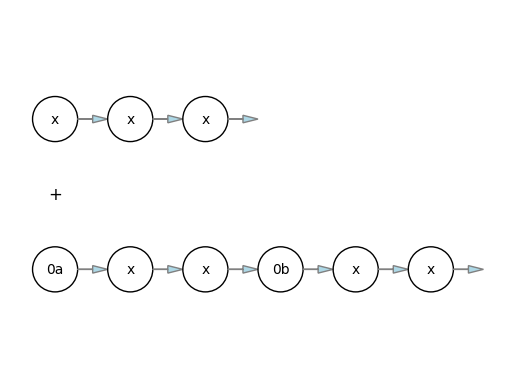

initial:  ['x', 'x', 'x']
after shifting:  ['x', 'x', 'x']
after merge:  ['0a', 'x', 'x', '0b', 'x', 'x']
after fitting ghosts:  ['0a', 'x', 'x', '0b', 'x', 'x']
after filling extra nodes:  ['0a', 'x', 'x', '0b', 'x', 'x']



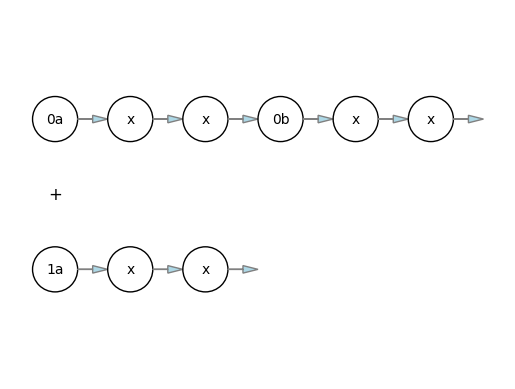

initial:  ['0a', 'x', 'x', '0b', 'x', 'x']
after shifting:  ['0a', 'x', 'x', '0b', 'x', 'x']
after merge:  ['0a', '1a', 'x', '0b', 'x', 'x']
after fitting ghosts:  ['0a', '1a', 'x', '0b', 'x', 'x']
after filling extra nodes:  ['0a', '1a', 'x', '0b', '1br', 'x']



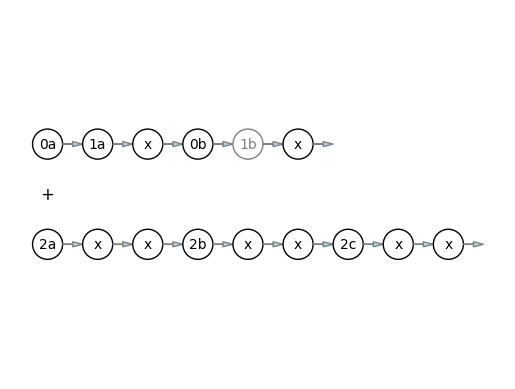

initial:  ['0a', '1a', 'x', '0b', 'x', 'x']
after shifting:  ['0a', '1a', 'x', '0b', 'x', 'x']
after merge:  ['0a', '1a', '2a', '0b', 'x', '2b', 'x', 'x', '2c', 'x', 'x']
after fitting ghosts:  ['0a', '1a', '2a', '0b', 'x', '2b', 'x', 'x', '2c']
after filling extra nodes:  ['0a', '1a', '2a', '0b', '1br', '2b', '0cr', '1br', '2c']



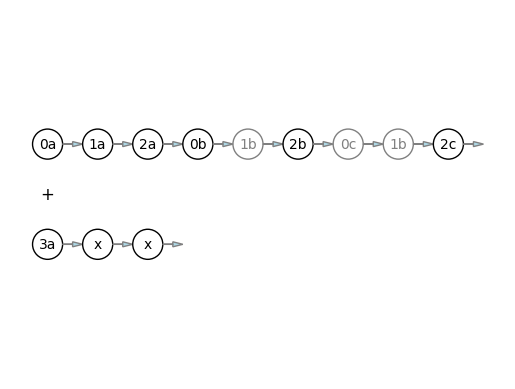

initial:  ['0a', '1a', '2a', '0b', 'x', '2b', 'x', 'x', '2c']
after shifting:  ['0a', '1a', '2a', '0b', 'x', '2b', 'x', 'x', '2c']
after merge:  ['0a', '1a', '2a', '0b', '3a', '2b', 'x', 'x', '2c']
after fitting ghosts:  ['0a', '1a', '2a', '0b', '3a', '2b', 'x', 'x', '2c']
after filling extra nodes:  ['0a', '1a', '2a', '0b', '3a', '2b', '0cr', '1br', '2c']



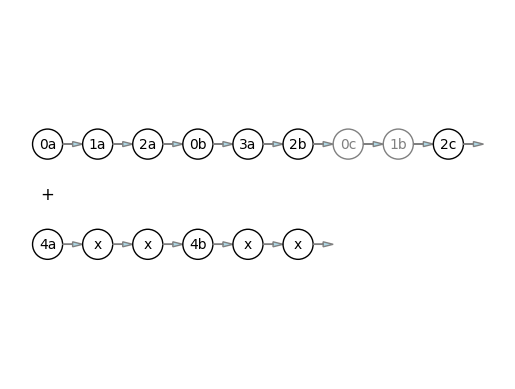

initial:  ['0a', '1a', '2a', '0b', '3a', '2b', 'x', 'x', '2c']
after shifting:  ['0a', '1a', '2a', '0b', '3a', '2b', 'x', 'x', '2c']
after merge:  ['0a', '1a', '2a', '0b', '3a', '2b', '4a', 'x', '2c', '4b', 'x', 'x']
after fitting ghosts:  ['0a', '1a', '2a', '0b', '3a', '2b', '4a', 'x', '2c', '4b', 'x', 'x']
after filling extra nodes:  ['0a', '1a', '2a', '0b', '3a', '2b', '4a', '3br', '2c', '4b', '3cr', '2br']



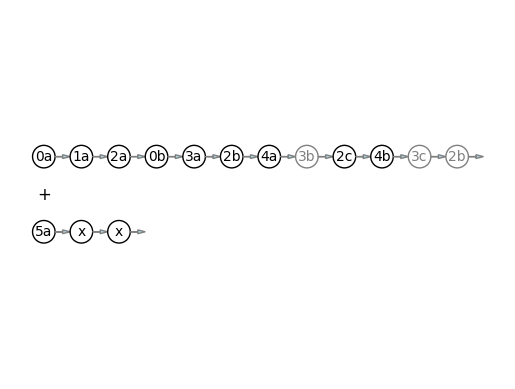

initial:  ['0a', '1a', '2a', '0b', '3a', '2b', '4a', 'x', '2c', '4b', 'x', 'x']
after shifting:  ['0a', '1a', '2a', '0b', '3a', '2b', '4a', 'x', '2c', '4b', 'x', 'x']
after merge:  ['0a', '1a', '2a', '0b', '3a', '2b', '4a', '5a', '2c', '4b', 'x', 'x']
after fitting ghosts:  ['0a', '1a', '2a', '0b', '3a', '2b', '4a', '5a', '2c', '4b', 'x', 'x']
after filling extra nodes:  ['0a', '1a', '2a', '0b', '3a', '2b', '4a', '5a', '2c', '4b', '5br', '2br']



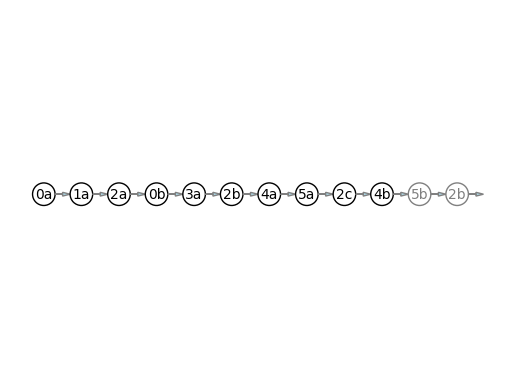

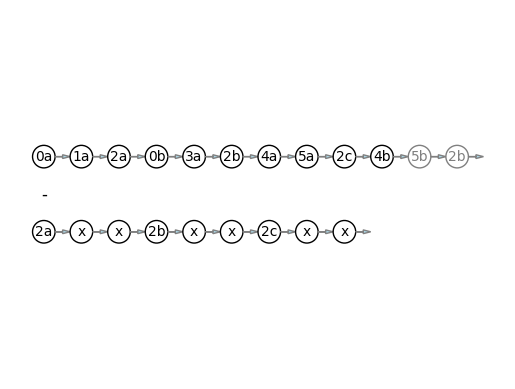

initial:  ['0a', '1a', '2a', '0b', '3a', '2b', '4a', '5a', '2c', '4b', 'x', 'x']
after deletion:  ['0a', '1a', 'x', '0b', '3a', 'x', '4a', '5a', 'x', '4b', 'x', 'x']
shortest stack idx:  2  with length:  0
max elems idx:  1  with length:  3
after balancing:  ['0a', '3a', '1a', '0b', '5a', 'x', '4a', 'x', 'x', '4b', 'x', 'x']
after shifting:  ['0a', '3a', '1a', '0b', '5a', 'x', '4a', 'x', 'x', '4b', 'x', 'x']
after fitting ghosts:  ['0a', '3a', '1a', '0b', '5a', 'x', '4a', 'x', 'x', '4b', 'x', 'x']
after filling extra nodes:  ['0a', '3a', '1a', '0b', '5a', '1br', '4a', '5br', '1cr', '4b', '5cr', '1br']



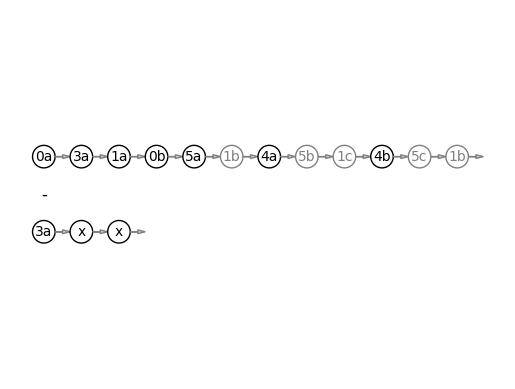

initial:  ['0a', '3a', '1a', '0b', '5a', 'x', '4a', 'x', 'x', '4b', 'x', 'x']
after deletion:  ['0a', 'x', '1a', '0b', '5a', 'x', '4a', 'x', 'x', '4b', 'x', 'x']
shortest stack idx:  1  with length:  1
max elems idx:  0  with length:  4
after balancing:  ['x', '5a', '1a', '4a', '0a', 'x', '4b', '0b', 'x', 'x', 'x', 'x']
after shifting:  ['4a', '5a', '1a', '4b', '0a', 'x', 'x', '0b', 'x', 'x', 'x', 'x']
after fitting ghosts:  ['4a', '5a', '1a', '4b', '0a', 'x', 'x', '0b', 'x']
after filling extra nodes:  ['4a', '5a', '1a', '4b', '0a', '1br', '4cr', '0b', '1cr']



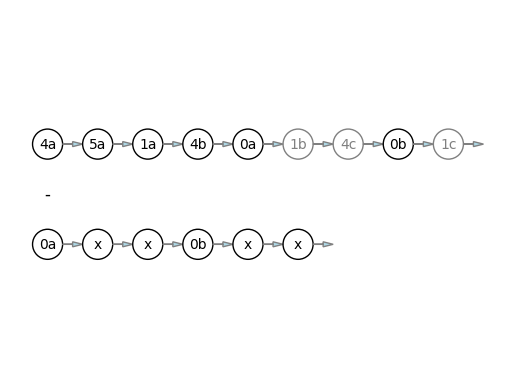

initial:  ['4a', '5a', '1a', '4b', '0a', 'x', 'x', '0b', 'x']
after deletion:  ['4a', '5a', '1a', '4b', 'x', 'x', 'x', 'x', 'x']
shortest stack idx:  1  with length:  1
max elems idx:  0  with length:  2
after balancing:  ['4a', '5a', '1a', '4b', 'x', 'x', 'x', 'x', 'x']
after shifting:  ['4a', '5a', '1a', '4b', 'x', 'x', 'x', 'x', 'x']
after fitting ghosts:  ['4a', '5a', '1a', '4b', 'x', 'x']
after filling extra nodes:  ['4a', '5a', '1a', '4b', '5br', '1br']



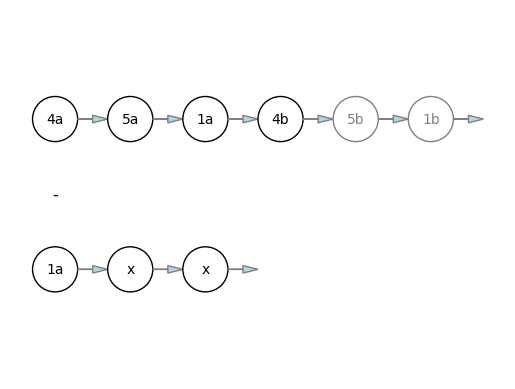

initial:  ['4a', '5a', '1a', '4b', 'x', 'x']
after deletion:  ['4a', '5a', 'x', '4b', 'x', 'x']
shortest stack idx:  2  with length:  0
max elems idx:  0  with length:  2
after balancing:  ['4a', '5a', 'x', '4b', 'x', 'x']
after shifting:  ['4a', '5a', 'x', '4b', 'x', 'x']
after fitting ghosts:  ['4a', '5a', 'x', '4b', 'x', 'x']
after filling extra nodes:  ['4a', '5a', 'x', '4b', '5br', 'x']



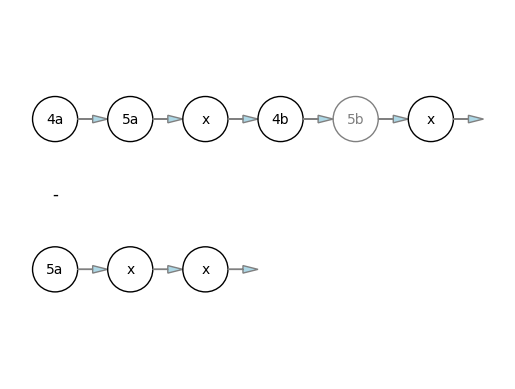

initial:  ['4a', '5a', 'x', '4b', 'x', 'x']
after deletion:  ['4a', 'x', 'x', '4b', 'x', 'x']
shortest stack idx:  1  with length:  0
max elems idx:  0  with length:  2
after balancing:  ['4a', 'x', 'x', '4b', 'x', 'x']
after shifting:  ['4a', 'x', 'x', '4b', 'x', 'x']
after fitting ghosts:  ['4a', 'x', 'x', '4b', 'x', 'x']
after filling extra nodes:  ['4a', 'x', 'x', '4b', 'x', 'x']



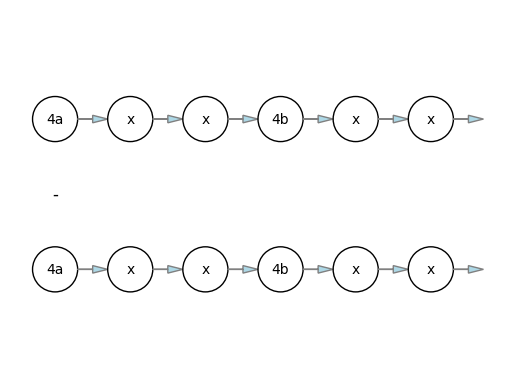

initial:  ['4a', 'x', 'x', '4b', 'x', 'x']
after deletion:  ['x', 'x', 'x', 'x', 'x', 'x']
after balancing:  ['x', 'x', 'x', 'x', 'x', 'x']
after shifting:  ['x', 'x', 'x', 'x', 'x', 'x']
after fitting ghosts:  ['x', 'x', 'x']
after filling extra nodes:  ['x', 'x', 'x']



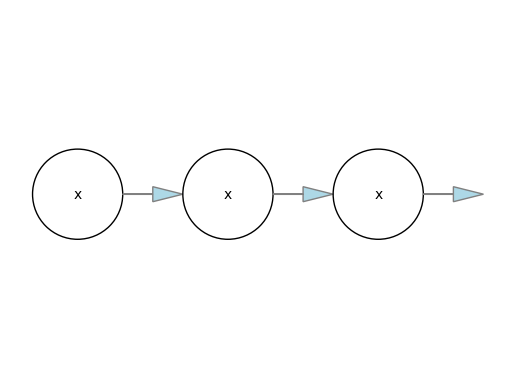

In [318]:
proc = {0:2, 1:1, 2:3, 3:1, 4:2, 5:1}
b = 3

gr = ['x' for _ in range(b)]

for p in proc:
    links = [(gr[i],gr[i+1]) for i in range(len(gr)-1)]
    plot_graph(gr, links, ypos=0, process=(p, proc[p]), sign='+')
    pr = process(str(p), proc[p])
    insert_process(b, gr, pr)
    print()
links = [(gr[i],gr[i+1]) for i in range(len(gr)-1)]
plot_graph(gr, links, ypos=0)

to_delete = [2, 3, 0, 1, 5, 4]
for p in to_delete:
    links = [(gr[i],gr[i+1]) for i in range(len(gr)-1)]
    plot_graph(gr, links, ypos=0, process=(p, proc[p]), sign='-')
    pr = process(str(p), proc[p])
    delete_process(b, gr, pr)
    print()
links = [(gr[i],gr[i+1]) for i in range(len(gr)-1)]
plot_graph(gr, links, ypos=0)

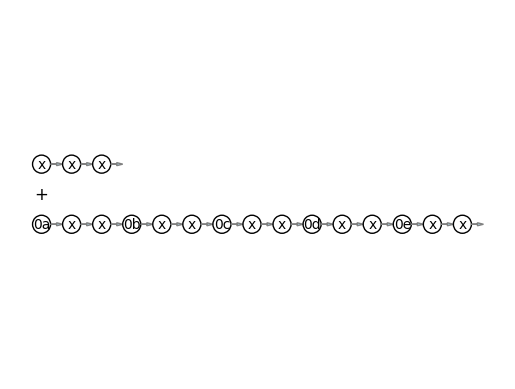

initial:  ['x', 'x', 'x']
after shifting:  ['x', 'x', 'x']
after merge:  ['0a', 'x', 'x', '0b', 'x', 'x', '0c', 'x', 'x', '0d', 'x', 'x', '0e', 'x', 'x']
after fitting ghosts:  ['0a', 'x', 'x', '0b', 'x', 'x', '0c', 'x', 'x', '0d', 'x', 'x', '0e', 'x', 'x']
after filling extra nodes:  ['0a', 'x', 'x', '0b', 'x', 'x', '0c', 'x', 'x', '0d', 'x', 'x', '0e', 'x', 'x']



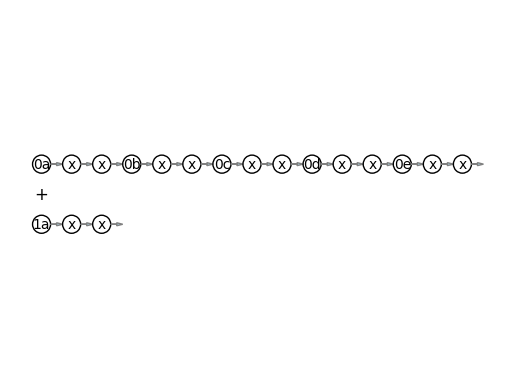

initial:  ['0a', 'x', 'x', '0b', 'x', 'x', '0c', 'x', 'x', '0d', 'x', 'x', '0e', 'x', 'x']
after shifting:  ['0a', 'x', 'x', '0b', 'x', 'x', '0c', 'x', 'x', '0d', 'x', 'x', '0e', 'x', 'x']
after merge:  ['0a', '1a', 'x', '0b', 'x', 'x', '0c', 'x', 'x', '0d', 'x', 'x', '0e', 'x', 'x']
after fitting ghosts:  ['0a', '1a', 'x', '0b', 'x', 'x', '0c', 'x', 'x', '0d', 'x', 'x', '0e', 'x', 'x']
after filling extra nodes:  ['0a', '1a', 'x', '0b', '1br', 'x', '0c', '1cr', 'x', '0d', '1dr', 'x', '0e', '1br', 'x']



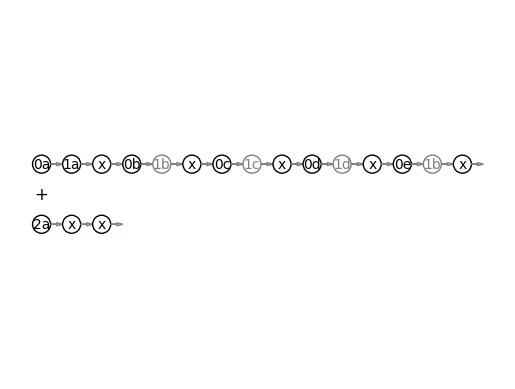

initial:  ['0a', '1a', 'x', '0b', 'x', 'x', '0c', 'x', 'x', '0d', 'x', 'x', '0e', 'x', 'x']
after shifting:  ['0a', '1a', 'x', '0b', 'x', 'x', '0c', 'x', 'x', '0d', 'x', 'x', '0e', 'x', 'x']
after merge:  ['0a', '1a', '2a', '0b', 'x', 'x', '0c', 'x', 'x', '0d', 'x', 'x', '0e', 'x', 'x']
after fitting ghosts:  ['0a', '1a', '2a', '0b', 'x', 'x', '0c', 'x', 'x', '0d', 'x', 'x', '0e', 'x', 'x']
after filling extra nodes:  ['0a', '1a', '2a', '0b', '1br', '2br', '0c', '1cr', '2cr', '0d', '1dr', '2dr', '0e', '1br', '2er']



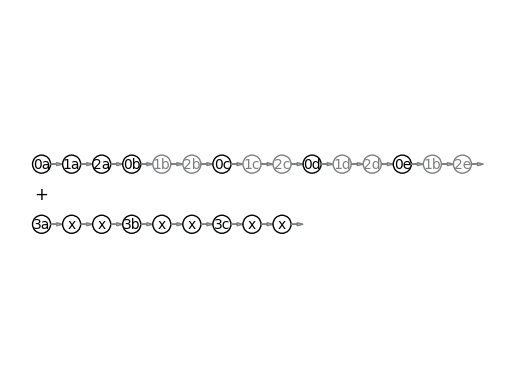

initial:  ['0a', '1a', '2a', '0b', 'x', 'x', '0c', 'x', 'x', '0d', 'x', 'x', '0e', 'x', 'x']
after shifting:  ['0a', '1a', '2a', '0b', 'x', 'x', '0c', 'x', 'x', '0d', 'x', 'x', '0e', 'x', 'x']
after merge:  ['0a', '1a', '2a', '0b', '3a', 'x', '0c', '3b', 'x', '0d', '3c', 'x', '0e', 'x', 'x']
after fitting ghosts:  ['0a', '1a', '2a', '0b', '3a', 'x', '0c', '3b', 'x', '0d', '3c', 'x', '0e', 'x', 'x']
after filling extra nodes:  ['0a', '1a', '2a', '0b', '3a', '2br', '0c', '3b', '2cr', '0d', '3c', '2dr', '0e', '1br', '2er']



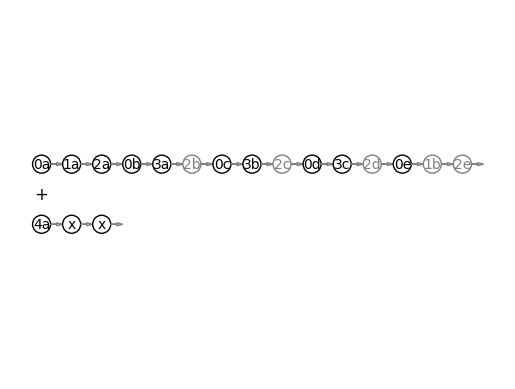

initial:  ['0a', '1a', '2a', '0b', '3a', 'x', '0c', '3b', 'x', '0d', '3c', 'x', '0e', 'x', 'x']
after shifting:  ['0a', '1a', '2a', '0b', '3a', 'x', '0c', '3b', 'x', '0d', '3c', 'x', '0e', 'x', 'x']
after merge:  ['0a', '1a', '2a', '0b', '3a', '4a', '0c', '3b', 'x', '0d', '3c', 'x', '0e', 'x', 'x']
after fitting ghosts:  ['0a', '1a', '2a', '0b', '3a', '4a', '0c', '3b', 'x', '0d', '3c', 'x', '0e', 'x', 'x']
after filling extra nodes:  ['0a', '1a', '2a', '0b', '3a', '4a', '0c', '3b', '4br', '0d', '3c', '4cr', '0e', '1br', '4dr']



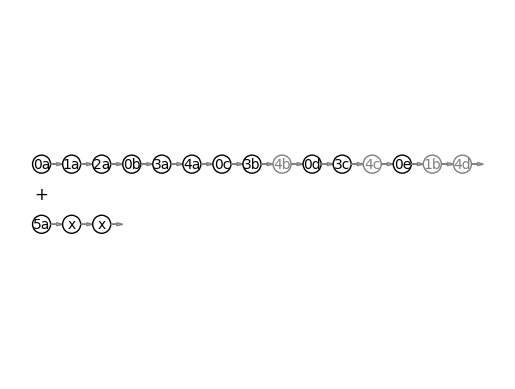

initial:  ['0a', '1a', '2a', '0b', '3a', '4a', '0c', '3b', 'x', '0d', '3c', 'x', '0e', 'x', 'x']
after shifting:  ['0a', '1a', '2a', '0b', '3a', '4a', '0c', '3b', 'x', '0d', '3c', 'x', '0e', 'x', 'x']
after merge:  ['0a', '1a', '2a', '0b', '3a', '4a', '0c', '3b', '5a', '0d', '3c', 'x', '0e', 'x', 'x']
after fitting ghosts:  ['0a', '1a', '2a', '0b', '3a', '4a', '0c', '3b', '5a', '0d', '3c', 'x', '0e', 'x', 'x']
after filling extra nodes:  ['0a', '1a', '2a', '0b', '3a', '4a', '0c', '3b', '5a', '0d', '3c', '5br', '0e', '1br', '5cr']



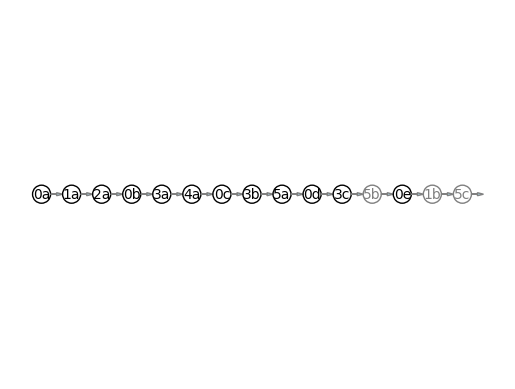

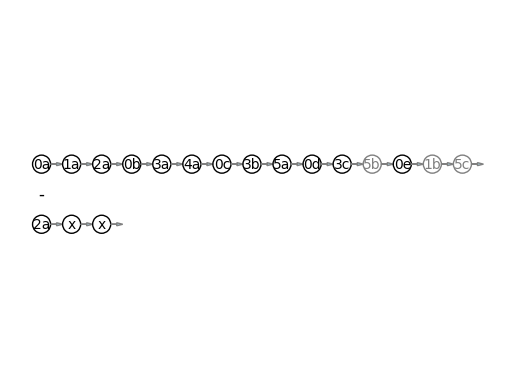

initial:  ['0a', '1a', '2a', '0b', '3a', '4a', '0c', '3b', '5a', '0d', '3c', 'x', '0e', 'x', 'x']
after deletion:  ['0a', '1a', 'x', '0b', '3a', '4a', '0c', '3b', '5a', '0d', '3c', 'x', '0e', 'x', 'x']
shortest stack idx:  2  with length:  2
max elems idx:  1  with length:  4
after balancing:  ['0a', '3a', '4a', '0b', '3b', '5a', '0c', '3c', '1a', '0d', 'x', 'x', '0e', 'x', 'x']
after shifting:  ['0a', '3a', '4a', '0b', '3b', '5a', '0c', '3c', '1a', '0d', 'x', 'x', '0e', 'x', 'x']
after fitting ghosts:  ['0a', '3a', '4a', '0b', '3b', '5a', '0c', '3c', '1a', '0d', 'x', 'x', '0e', 'x', 'x']
after filling extra nodes:  ['0a', '3a', '4a', '0b', '3b', '5a', '0c', '3c', '1a', '0d', '3dr', '1br', '0e', '3br', '1cr']



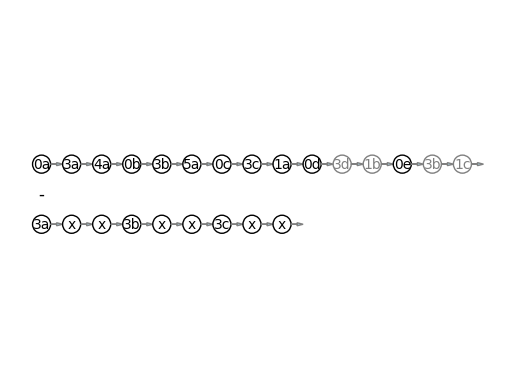

initial:  ['0a', '3a', '4a', '0b', '3b', '5a', '0c', '3c', '1a', '0d', 'x', 'x', '0e', 'x', 'x']
after deletion:  ['0a', 'x', '4a', '0b', 'x', '5a', '0c', 'x', '1a', '0d', 'x', 'x', '0e', 'x', 'x']
shortest stack idx:  1  with length:  0
max elems idx:  2  with length:  3
after balancing:  ['0a', '4a', '5a', '0b', 'x', '1a', '0c', 'x', 'x', '0d', 'x', 'x', '0e', 'x', 'x']
after shifting:  ['0a', '4a', '5a', '0b', 'x', '1a', '0c', 'x', 'x', '0d', 'x', 'x', '0e', 'x', 'x']
after fitting ghosts:  ['0a', '4a', '5a', '0b', 'x', '1a', '0c', 'x', 'x', '0d', 'x', 'x', '0e', 'x', 'x']
after filling extra nodes:  ['0a', '4a', '5a', '0b', '4br', '1a', '0c', '4cr', '1br', '0d', '4dr', '1cr', '0e', '4br', '1dr']



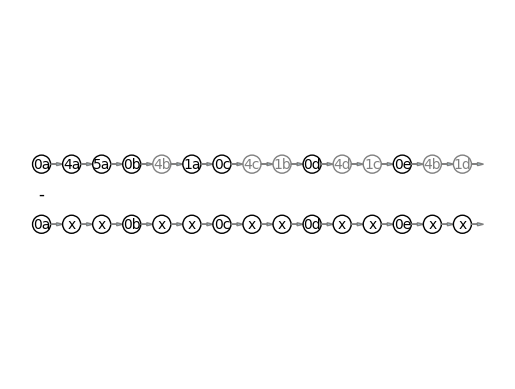

initial:  ['0a', '4a', '5a', '0b', 'x', '1a', '0c', 'x', 'x', '0d', 'x', 'x', '0e', 'x', 'x']
after deletion:  ['x', '4a', '5a', 'x', 'x', '1a', 'x', 'x', 'x', 'x', 'x', 'x', 'x', 'x', 'x']
shortest stack idx:  0  with length:  0
max elems idx:  2  with length:  2
after balancing:  ['5a', '4a', '1a', 'x', 'x', 'x', 'x', 'x', 'x', 'x', 'x', 'x', 'x', 'x', 'x']
after shifting:  ['5a', '4a', '1a', 'x', 'x', 'x', 'x', 'x', 'x', 'x', 'x', 'x', 'x', 'x', 'x']
after fitting ghosts:  ['5a', '4a', '1a']
after filling extra nodes:  ['5a', '4a', '1a']



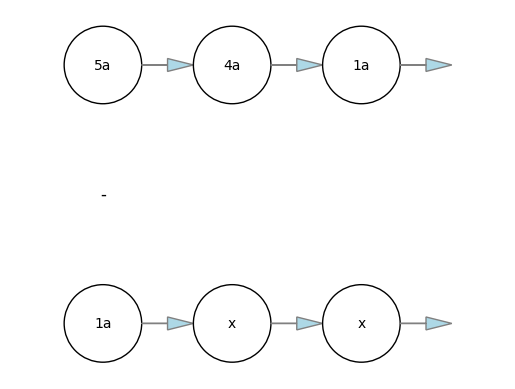

initial:  ['5a', '4a', '1a']
after deletion:  ['5a', '4a', 'x']
shortest stack idx:  2  with length:  0
max elems idx:  0  with length:  1
after balancing:  ['5a', '4a', 'x']
after shifting:  ['5a', '4a', 'x']
after fitting ghosts:  ['5a', '4a', 'x']
after filling extra nodes:  ['5a', '4a', 'x']



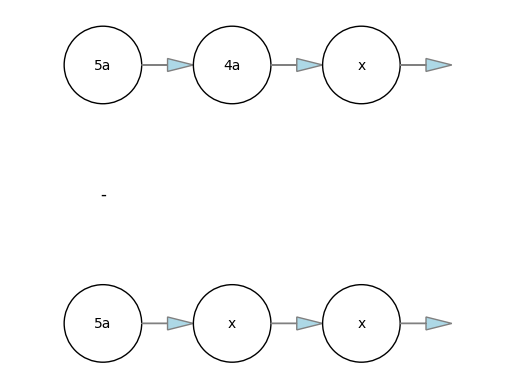

initial:  ['5a', '4a', 'x']
after deletion:  ['x', '4a', 'x']
shortest stack idx:  0  with length:  0
max elems idx:  1  with length:  1
after balancing:  ['x', '4a', 'x']
after shifting:  ['x', '4a', 'x']
after fitting ghosts:  ['x', '4a', 'x']
after filling extra nodes:  ['x', '4a', 'x']



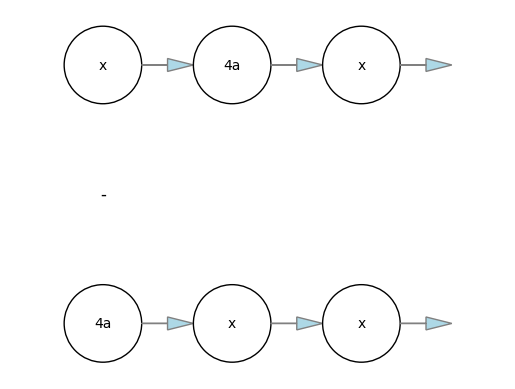

initial:  ['x', '4a', 'x']
after deletion:  ['x', 'x', 'x']
after balancing:  ['x', 'x', 'x']
after shifting:  ['x', 'x', 'x']
after fitting ghosts:  ['x', 'x', 'x']
after filling extra nodes:  ['x', 'x', 'x']



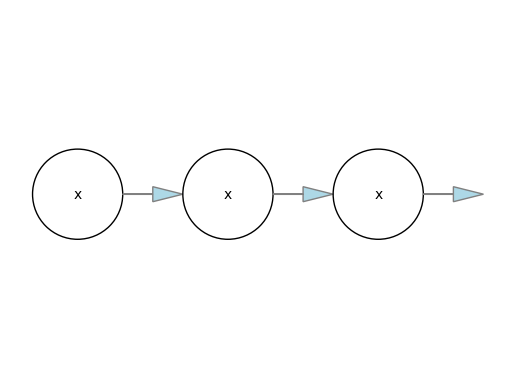

In [319]:
proc = {0:5, 1:1, 2:1, 3:3, 4:1, 5:1}
b = 3

gr = ['x' for _ in range(b)]

for p in proc:
    links = [(gr[i],gr[i+1]) for i in range(len(gr)-1)]
    plot_graph(gr, links, ypos=0, process=(p, proc[p]), sign='+')
    pr = process(str(p), proc[p])
    insert_process(b, gr, pr)
    print()
links = [(gr[i],gr[i+1]) for i in range(len(gr)-1)]
plot_graph(gr, links, ypos=0)

to_delete = [2, 3, 0, 1, 5, 4]
for p in to_delete:
    links = [(gr[i],gr[i+1]) for i in range(len(gr)-1)]
    plot_graph(gr, links, ypos=0, process=(p, proc[p]), sign='-')
    pr = process(str(p), proc[p])
    delete_process(b, gr, pr)
    print()
links = [(gr[i],gr[i+1]) for i in range(len(gr)-1)]
plot_graph(gr, links, ypos=0)